# SMF 02b · Per-cluster SMFs

The same membership-corrected SMF as in `02a` for each of the nine clusters separately (within R200): first worked through step by step for one cluster, then as a function run for all clusters. Produces the per-cluster figures (Figures 10, 11), the machine-readable SMF table (Table 4) and the table of Schechter parameters.

**Inputs** (not included): `DATA/MACH_MASS/MACH_DR18_3R200_mastercat.csv`, `DATA/MACH_PHOT/AllHeCS_VAC_updated.csv`, `MACH_SMF_fspec_fmem_bin.csv`

**Outputs**: `SMF_results/<cluster>_single_results.npz`, `Table4_MRT.txt`, `SMF_Fit_Params_Table.csv`, `FIGURE/IMAGES/Figure10.pdf`, `Figure11.pdf`

In [12]:
# ============================================================================
# Setup
# ============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from astropy.cosmology import LambdaCDM

# Cosmology used throughout this project
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

# Matplotlib style shared by the notebooks of this repository
plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,
    'lines.linewidth': 2,
    'axes.linewidth': 4,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})

# Show every column when a DataFrame is displayed
pd.set_option('display.max_columns', None)

# The nine MACH clusters
MACHLIST = ['A2245', 'A1767', 'A2244', 'A1831', 'A2034', 'A7', 'A2255', 'A2029', 'A2065']

# Repository root, located relative to this notebook; DATA/ and FIGURE/ hang off it
MAINPATH = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
FIGUREPATH = f"{MAINPATH}/FIGURE/IMAGES"

%config InlineBackend.figure_format = 'retina'

In [13]:
# Load MACH master catalog
mach_path = f"{MAINPATH}/DATA/MACH_MASS/MACH_DR18_3R200_mastercat.csv"
mach_data = pd.read_csv(mach_path)

# Correct cmodel magnitudes for extinction
for band in ("g", "r"):
    mach_data[f"cmodelMag_{band}_0"] = (
        mach_data[f"cmodelMag_{band}"] - mach_data[f"extinction_{band}"]
    )

# Load HeCS VAC catalog
hecs_vac_path = f"{MAINPATH}/DATA/MACH_PHOT/AllHeCS_VAC_updated.csv"
hecs_vac_data = pd.read_csv(hecs_vac_path)

# Galaxies within 1 R200
df = mach_data.loc[mach_data["Rcl/R200"] <= 1.0].copy()

# Construct Mock_z: use Z_TOT_Z, but if Z_TOT_Z == -99, use cluster mean z from hecs_vac_data (by CLID)
df["Mock_z"] = df["Z_TOT_Z"]

# Find rows with Z_TOT_Z == -99
mask_noz = (df["Z_TOT_Z"] == -99)

# For those rows, replace with matching cluster z from hecs_vac_data
if "CLID" in df.columns and "CLID" in hecs_vac_data.columns:
    # Construct cluster z dictionary from hecs_vac_data
    clid_to_z = hecs_vac_data.set_index("CLID")["Z"].to_dict()
    # Fill Mock_z for those without z
    df.loc[mask_noz, "Mock_z"] = df.loc[mask_noz, "CLID"].map(clid_to_z)

# Compute absolute r-band magnitude using Mock_z
lum_dist_pc = cosmo.luminosity_distance(df["Mock_z"]).to("pc").value
df["AbsMag_r"] = df["cmodelMag_r_0"] - 5 * np.log10(lum_dist_pc / 10)

/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_70233/144342032.py:34: RuntimeWarning: divide by zero encountered in log10
  df["AbsMag_r"] = df["cmodelMag_r_0"] - 5 * np.log10(lum_dist_pc / 10)
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_70233/144342032.py:34: RuntimeWarning: invalid value encountered in log10
  df["AbsMag_r"] = df["cmodelMag_r_0"] - 5 * np.log10(lum_dist_pc / 10)


# 1. Step-by-step correction for a single cluster

In [14]:
from scipy import stats
from tqdm import tqdm

# =============================================================
# Configuration
# =============================================================
TARGET        = 'A2029'
iterations    = 1000                              # Monte Carlo iterations
bin_min, bin_max, bin_width = 7, 13, 0.2         # stellar-mass histogram axis
bins          = np.arange(bin_min, bin_max + bin_width, bin_width)
bin_centers   = bins[:-1] + bin_width / 2

# 3D bin edges that were used when building df_correction
# (must be identical to those in 01_build_SMF_correct_param)
abs_mag_r_bins = np.arange(-30, 10, 1.00)        # absolute r-band magnitude
gr_bins        = np.arange(-6.5, 15.25, 0.25)    # (g-r) colour
rcl_r200_bins  = np.arange(0, 1.2, 0.20)         # projected cluster-centric radius / R200

# =============================================================
# Load membership-correction table
#   Columns: Mr_bin, color_bin, Rcl_bin, f_mem, f_spec
#   f_spec = spectroscopic completeness (Nspec / Nphot) per bin
#   f_mem  = membership probability for non-spectroscopic objects per bin
# =============================================================
df_correction = pd.read_csv('./MACH_SMF_fspec_fmem_bin.csv')

# The CSV stores bin labels as plain strings, e.g. "(-22.0, -21.0]".
# Force string type and strip any stray whitespace so the merge is robust.
bin_keys = ['Mr_bin', 'color_bin', 'Rcl_bin']
for _k in bin_keys:
    df_correction[_k] = df_correction[_k].astype(str).str.strip()

# =============================================================
# Step 1 – Prepare working catalogue
# =============================================================
# Start from df (already filtered to Rcl/R200 <= 1.0 in the earlier cell).
# Drop rows with missing extinction-corrected photometry.
definition = df[df['CLID']==TARGET].copy()
definition = definition[
    (definition['cmodelMag_g'] != -9999.0) &
    (definition['cmodelMag_r'] != -9999.0)
].copy()

num_clusters = 1

# =============================================================
# Step 2 – Derive (g-r) colour and assign galaxies to 3D bins
# =============================================================
# Extinction-corrected (g-r) colour
definition['g_r'] = definition['cmodelMag_g_0'] - definition['cmodelMag_r_0']

# Assign each galaxy to its (AbsMag_r, g-r, Rcl/R200) bin cell.
# pd.cut returns Interval objects; convert to the same string format as
# df_correction so the merge below finds exact matches.
def _iv_to_str(iv):
    """Convert a pandas Interval to the same string label used in the CSV."""
    return np.nan if pd.isna(iv) else f"({iv.left}, {iv.right}]"

definition['Mr_bin']    = pd.cut(definition['AbsMag_r'],  bins=abs_mag_r_bins).apply(_iv_to_str)
definition['color_bin'] = pd.cut(definition['g_r'],       bins=gr_bins       ).apply(_iv_to_str)
definition['Rcl_bin']   = pd.cut(definition['Rcl/R200'],  bins=rcl_r200_bins ).apply(_iv_to_str)

# =============================================================
# Step 3 – Build DN4000_predicted
#   Use the measured Z_TOT_DN4000 where available (≠ -99.0).
#   For galaxies without a spectrum, predict DN4000 from a linear
#   regression on (g-r) colour trained on the spectroscopic sub-sample.
# =============================================================
train_mask = definition['Z_TOT_DN4000'] != -99.0
train_data = definition[train_mask]

slope, intercept, r_val, *_ = stats.linregress(
    train_data['g_r'], train_data['Z_TOT_DN4000']
)
print(f"DN4000 regression:  DN4000 = {slope:.4f}*(g-r) + {intercept:.4f}  "
      f"(R²={r_val**2:.3f},  N_train={train_mask.sum()})")

definition['DN4000_predicted'] = np.where(
    train_mask,
    definition['Z_TOT_DN4000'],              # measured value
    intercept + slope * definition['g_r']    # regression prediction
)

# =============================================================
# Step 4 – Attach f_mem and f_spec from the correction table
#   Left-join on the 3 bin columns; rows whose bin is absent from
#   df_correction will have f_mem = f_spec = NaN (handled in Step 5).
# =============================================================
definition = definition.merge(
    df_correction[bin_keys + ['f_mem', 'f_spec']],
    on=bin_keys,
    how='left'
)

# =============================================================
# Step 5 – Compute N_cor (number of non-spec objects to draw) per bin
#
#   For each (Mr_bin, color_bin, Rcl_bin) cell:
#     Nphot = total galaxies in the cell
#     Nspec = galaxies with a measured redshift  (Z_TOT_Z ≠ -99.0)
#     Nnon  = Nphot - Nspec  →  photometric-only (no redshift) objects
#     N_cor = round( Nnon * f_mem )
#           = estimated number of true cluster members hiding in
#             the non-spectroscopic pool that should be added back
#
#   Bins not present in df_correction have f_mem = NaN → treated as 0,
#   so N_cor = 0 (no objects drawn from those cells).
# =============================================================
def _compute_ncor(group):
    Nphot  = len(group)
    Nspec  = (group['Z_TOT_Z'] != -99.0).sum()
    Nnon   = Nphot - Nspec                       # non-spectroscopic objects
    f_mem  = group['f_mem'].iat[0]
    f_spec = group['f_spec'].iat[0]
    if pd.isna(f_mem):  f_mem  = 0.0
    if pd.isna(f_spec): f_spec = 0.0
    N_cor  = int(round(Nnon * f_mem))
    return pd.Series({'Nphot': Nphot, 'Nspec': Nspec, 'Nnon': Nnon,
                      'f_mem': f_mem, 'f_spec': f_spec, 'N_cor': N_cor})

bin_stats = (
    definition
    .groupby(bin_keys, observed=True)
    .apply(_compute_ncor, include_groups=False)
    .reset_index()
)

# Broadcast per-bin statistics back onto every row of definition
# so we can inspect Nphot / Nspec / N_cor column-by-column.
definition = definition.merge(
    bin_stats[bin_keys + ['Nphot', 'Nspec', 'Nnon', 'N_cor']],
    on=bin_keys, how='left'
)
for _col in ['Nphot', 'Nspec', 'Nnon', 'N_cor']:
    definition[_col] = definition[_col].fillna(0).astype(int)

# Diagnostic summary
n_bins_nonzero = (bin_stats['N_cor'] > 0).sum()
print(f"Bins with N_cor > 0 : {n_bins_nonzero} / {len(bin_stats)}")
print(f"Rows with N_cor > 0 : {(definition['N_cor'] > 0).sum()} / {len(definition)}")
print(f"Total N_cor (sum)   : {definition['N_cor'].sum()}")
display(
    bin_stats[bin_stats['N_cor'] > 0][bin_keys + ['Nphot','Nspec','Nnon','f_mem','f_spec','N_cor']]
    .sort_values('N_cor', ascending=False)
    .head(20)
)

# Fast bin-key → N_cor lookup used inside the MC loop
ncor_lookup = {
    tuple(row[bin_keys]): int(row['N_cor'])
    for _, row in bin_stats.iterrows()
}

# =============================================================
# Step 6 – Separate spectroscopic members and non-spectroscopic pool
# =============================================================
# Confirmed spectroscopic cluster members (MEMBER == 'Y')
member_y_df = definition[definition['MEMBER'] == 'Y'].copy()
Nmem_raw    = len(member_y_df)

# Non-spectroscopic candidate pool:
#   – no measured redshift  (Z_TOT_Z == -99.0)
#   – not already a confirmed spectroscopic member
nonspec_pool = definition[
    (definition['Z_TOT_Z'] == -99.0) & (definition['MEMBER'] == 'N')
]

# Pre-group into a dict keyed by (Mr_bin, color_bin, Rcl_bin) for fast MC access
nonspec_grouped = {
    key: grp.reset_index(drop=True)
    for key, grp in nonspec_pool.groupby(bin_keys, observed=True)
}

# =============================================================
# Step 7 – Monte Carlo membership correction
#
#   In each iteration, randomly sample N_cor objects from the
#   non-spectroscopic pool for every non-empty bin cell.
#   Combine with confirmed members → completeness-corrected catalogue.
# =============================================================
hist_corrected = []    # total corrected SMF (all galaxies)
hist_quenched  = []    # quenched sub-population  (DN4000 > 1.5)
hist_sf        = []    # star-forming sub-population (DN4000 ≤ 1.5)

# Baseline: spec-member-only SMF (per cluster, averaged)
original_counts, _ = np.histogram(member_y_df['M_MASS_CIGALE_PARK'], bins=bins)
original_counts    = original_counts.astype(float) / num_clusters

for _ in tqdm(range(iterations), desc="Monte Carlo"):
    sampled_frames = []

    for bin_key, group in nonspec_grouped.items():
        n_cor = ncor_lookup.get(bin_key, 0)
        if n_cor > 0:
            # Never request more objects than the pool contains
            n_draw = min(n_cor, len(group))
            sampled_frames.append(group.sample(n=n_draw, replace=False))

    if sampled_frames:
        sampled_df    = pd.concat(sampled_frames, ignore_index=True)
        final_catalog = pd.concat([member_y_df, sampled_df], ignore_index=True)
    else:
        final_catalog = member_y_df.copy()

    # Stellar-mass histograms, normalised per cluster
    counts_all, _ = np.histogram(final_catalog['M_MASS_CIGALE_PARK'], bins=bins)
    hist_corrected.append(counts_all.astype(float) / num_clusters)

    q  = final_catalog[final_catalog['DN4000_predicted'] >  1.5]
    sf = final_catalog[final_catalog['DN4000_predicted'] <= 1.5]

    counts_q,  _ = np.histogram(q ['M_MASS_CIGALE_PARK'], bins=bins)
    counts_sf, _ = np.histogram(sf['M_MASS_CIGALE_PARK'], bins=bins)

    hist_quenched.append(counts_q .astype(float) / num_clusters)
    hist_sf.append      (counts_sf.astype(float) / num_clusters)

# =============================================================
# Step 8 – Mean histograms across MC iterations
# =============================================================
mean_all = np.mean(hist_corrected, axis=0)
mean_q   = np.mean(hist_quenched,  axis=0)
mean_sf  = np.mean(hist_sf,        axis=0)

# =============================================================
# Step 9 – Stellar-mass completeness limit
#   Find the lowest-mass bin where the photometric correction
#   (non-spec additions) exceeds 10 % of the raw spec-member count.
#   Bins below this limit are considered incomplete.
# =============================================================
excess_counts = (mean_all - original_counts) * num_clusters
excess_counts  = np.clip(excess_counts, 0, None)       # ignore negative residuals

# Cumulative excess from high mass → low mass
cumulative_excess = np.cumsum(excess_counts[::-1])[::-1]
threshold = 0.1 * Nmem_raw

idx = np.where(cumulative_excess >= threshold)[0][-1] if np.any(cumulative_excess >= threshold) else 0
SMF_complimit = round(bin_centers[idx] - 0.5 * bin_width, 3)
print(f"SMF mass completeness limit: log(M*/M☉) = {SMF_complimit}")

# =============================================================
# Outputs
#   original_counts  – baseline spec-member SMF (per cluster)
#   mean_all         – completeness-corrected total SMF (MC mean, per cluster)
#   mean_q           – corrected quenched SMF
#   mean_sf          – corrected star-forming SMF
#   SMF_complimit    – mass completeness limit [log M*]
#   definition       – working catalogue with Nphot, Nspec, Nnon, N_cor columns
# =============================================================

DN4000 regression:  DN4000 = 0.2316*(g-r) + 1.2063  (R²=0.026,  N_train=2141)
Bins with N_cor > 0 : 62 / 467
Rows with N_cor > 0 : 1700 / 4616
Total N_cor (sum)   : 65357


,Mr_bin,color_bin,Rcl_bin,Nphot,Nspec,Nnon,f_mem,f_spec,N_cor
117,"(-17.0, -16.0]","(0.75, 1.0]","(0.8, 1.0]",131.0,1.0,130.0,0.777778,0.006824,101.0
116,"(-17.0, -16.0]","(0.75, 1.0]","(0.6, 0.8]",99.0,2.0,97.0,0.900000,0.006824,87.0
115,"(-17.0, -16.0]","(0.75, 1.0]","(0.4, 0.6]",81.0,2.0,79.0,0.857143,0.006824,68.0
112,"(-17.0, -16.0]","(0.5, 0.75]","(0.8, 1.0]",115.0,0.0,115.0,0.545455,0.006824,63.0
114,"(-17.0, -16.0]","(0.75, 1.0]","(0.2, 0.4]",72.0,0.0,72.0,0.857143,0.006824,62.0
109,"(-17.0, -16.0]","(0.5, 0.75]","(0.2, 0.4]",63.0,2.0,61.0,0.882353,0.006824,54.0
110,"(-17.0, -16.0]","(0.5, 0.75]","(0.4, 0.6]",76.0,5.0,71.0,0.619048,0.006824,44.0
121,"(-17.0, -16.0]","(1.0, 1.25]","(0.6, 0.8]",62.0,1.0,61.0,0.666667,0.006824,41.0
107,"(-17.0, -16.0]","(0.25, 0.5]","(0.8, 1.0]",85.0,4.0,81.0,0.500000,0.006824,40.0
111,"(-17.0, -16.0]","(0.5, 0.75]","(0.6, 0.8]",114.0,3.0,111.0,0.333333,0.006824,37.0


Monte Carlo: 100%|██████████| 1000/1000 [00:14<00:00, 67.66it/s]

SMF mass completeness limit: log(M*/M☉) = 9.0


In [15]:
import emcee

# --- MCMC hyper-parameters ---
ndim       = 3        # number of free parameters
nwalkers   = 256       # number of walkers
burn_steps = 100     # burn-in steps
prod_steps = 500     # production steps

# --- Per-dataset initial guesses (phi0, M*, alpha) ---
initial_guesses = {
    'All':          np.array([333, 10.65, -1.00]),
    'Quiescent':    np.array([100, 10.70, -1.00]),
    'Star-forming': np.array([200, 10.10, -1.40]),
    'Original':     np.array([150, 10.50, -1.00]),
}

# --- Per-dataset marker symbols ---
marker_symbols = {
    'All':           'o',
    'Quiescent':     's',
    'Star-forming':  '^',
    'Original':      'D',
}

# --- Per-dataset colors ---
colors = {
    'All':           '#000000',  # black
    'Original':      "#bd8d35",  # brown
    'Star-forming':  '#1f77b4',  # blue
    'Quiescent':     '#d62728'   # red
}

# --- Schechter and probabilistic functions ---
def schechter_1D_SMF(M, phi_0, M_star, alpha):
    return (np.log(10) * phi_0 *
            (10 ** ((1 + alpha) * -(M_star - M))) *
            np.exp(-10 ** -(M_star - M)))

def log_prior(theta):
    phi_0, M_star, alpha = theta
    return 0.0 if (0 < phi_0 < 1e4 and -5 < alpha < 5 and 8 < M_star < 14) else -np.inf

def log_likelihood(theta, x, y, yerr):
    model = schechter_1D_SMF(x, *theta)
    inv_sigma = 1.0 / (yerr**2)
    return -0.5 * np.sum((y-model)**2 * inv_sigma + np.log(2*np.pi*yerr**2))

def log_posterior(theta, x, y, yerr):
    lp = log_prior(theta)
    return lp + log_likelihood(theta, x, y, yerr) if np.isfinite(lp) else -np.inf

# --- Data arrays & panel setup ---
datasets = {
    'Original':      original_counts,
    'All':           mean_all,
    'Quiescent':     mean_q,
    'Star-forming':  mean_sf,
}

panels = {
    0: ['Original', 'All'],
    1: ['All', 'Quiescent', 'Star-forming']
}
# assign distinct linestyles for each dataset
line_styles = {
    'All':           '-',   # solid
    'Original':      '--',  # dashed
    'Quiescent':     '-.',  # dash-dot
    'Star-forming':  ':'    # dotted
}

def fit_schechter_mcmc(x, y, yerr, initial):
    pos = initial + 1e-4 * np.random.randn(nwalkers, ndim)
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior,
                                    args=(x, y, yerr))
    sampler.run_mcmc(pos, burn_steps, progress=True)
    sampler.reset()
    sampler.run_mcmc(None, prod_steps, progress=True)
    samples = sampler.get_chain(flat=True)

    # compute 16th, 50th, 84th percentiles
    perc = np.percentile(samples, [16, 50, 84], axis=0)
    lower = perc[1] - perc[0]
    median = perc[1]
    upper = perc[2] - perc[1]
    return median, lower, upper

# --- 1) Compute all fits once (now with errors) ---
fit_results = {}
for label, hist in datasets.items():
    hist_norm = hist / bin_width
    yerr_up   = (np.sqrt(hist + 0.75) + 1) / bin_width
    mask      = (bin_centers > SMF_complimit) & (hist_norm > 0)
    x_fit     = bin_centers[mask]
    y_fit     = hist_norm[mask]
    yerr      = yerr_up[mask]
    fit_results[label] = fit_schechter_mcmc(
        x_fit, y_fit, yerr, initial_guesses[label]
    )

100%|██████████| 500/500 [00:01<00:00, 254.48it/s]


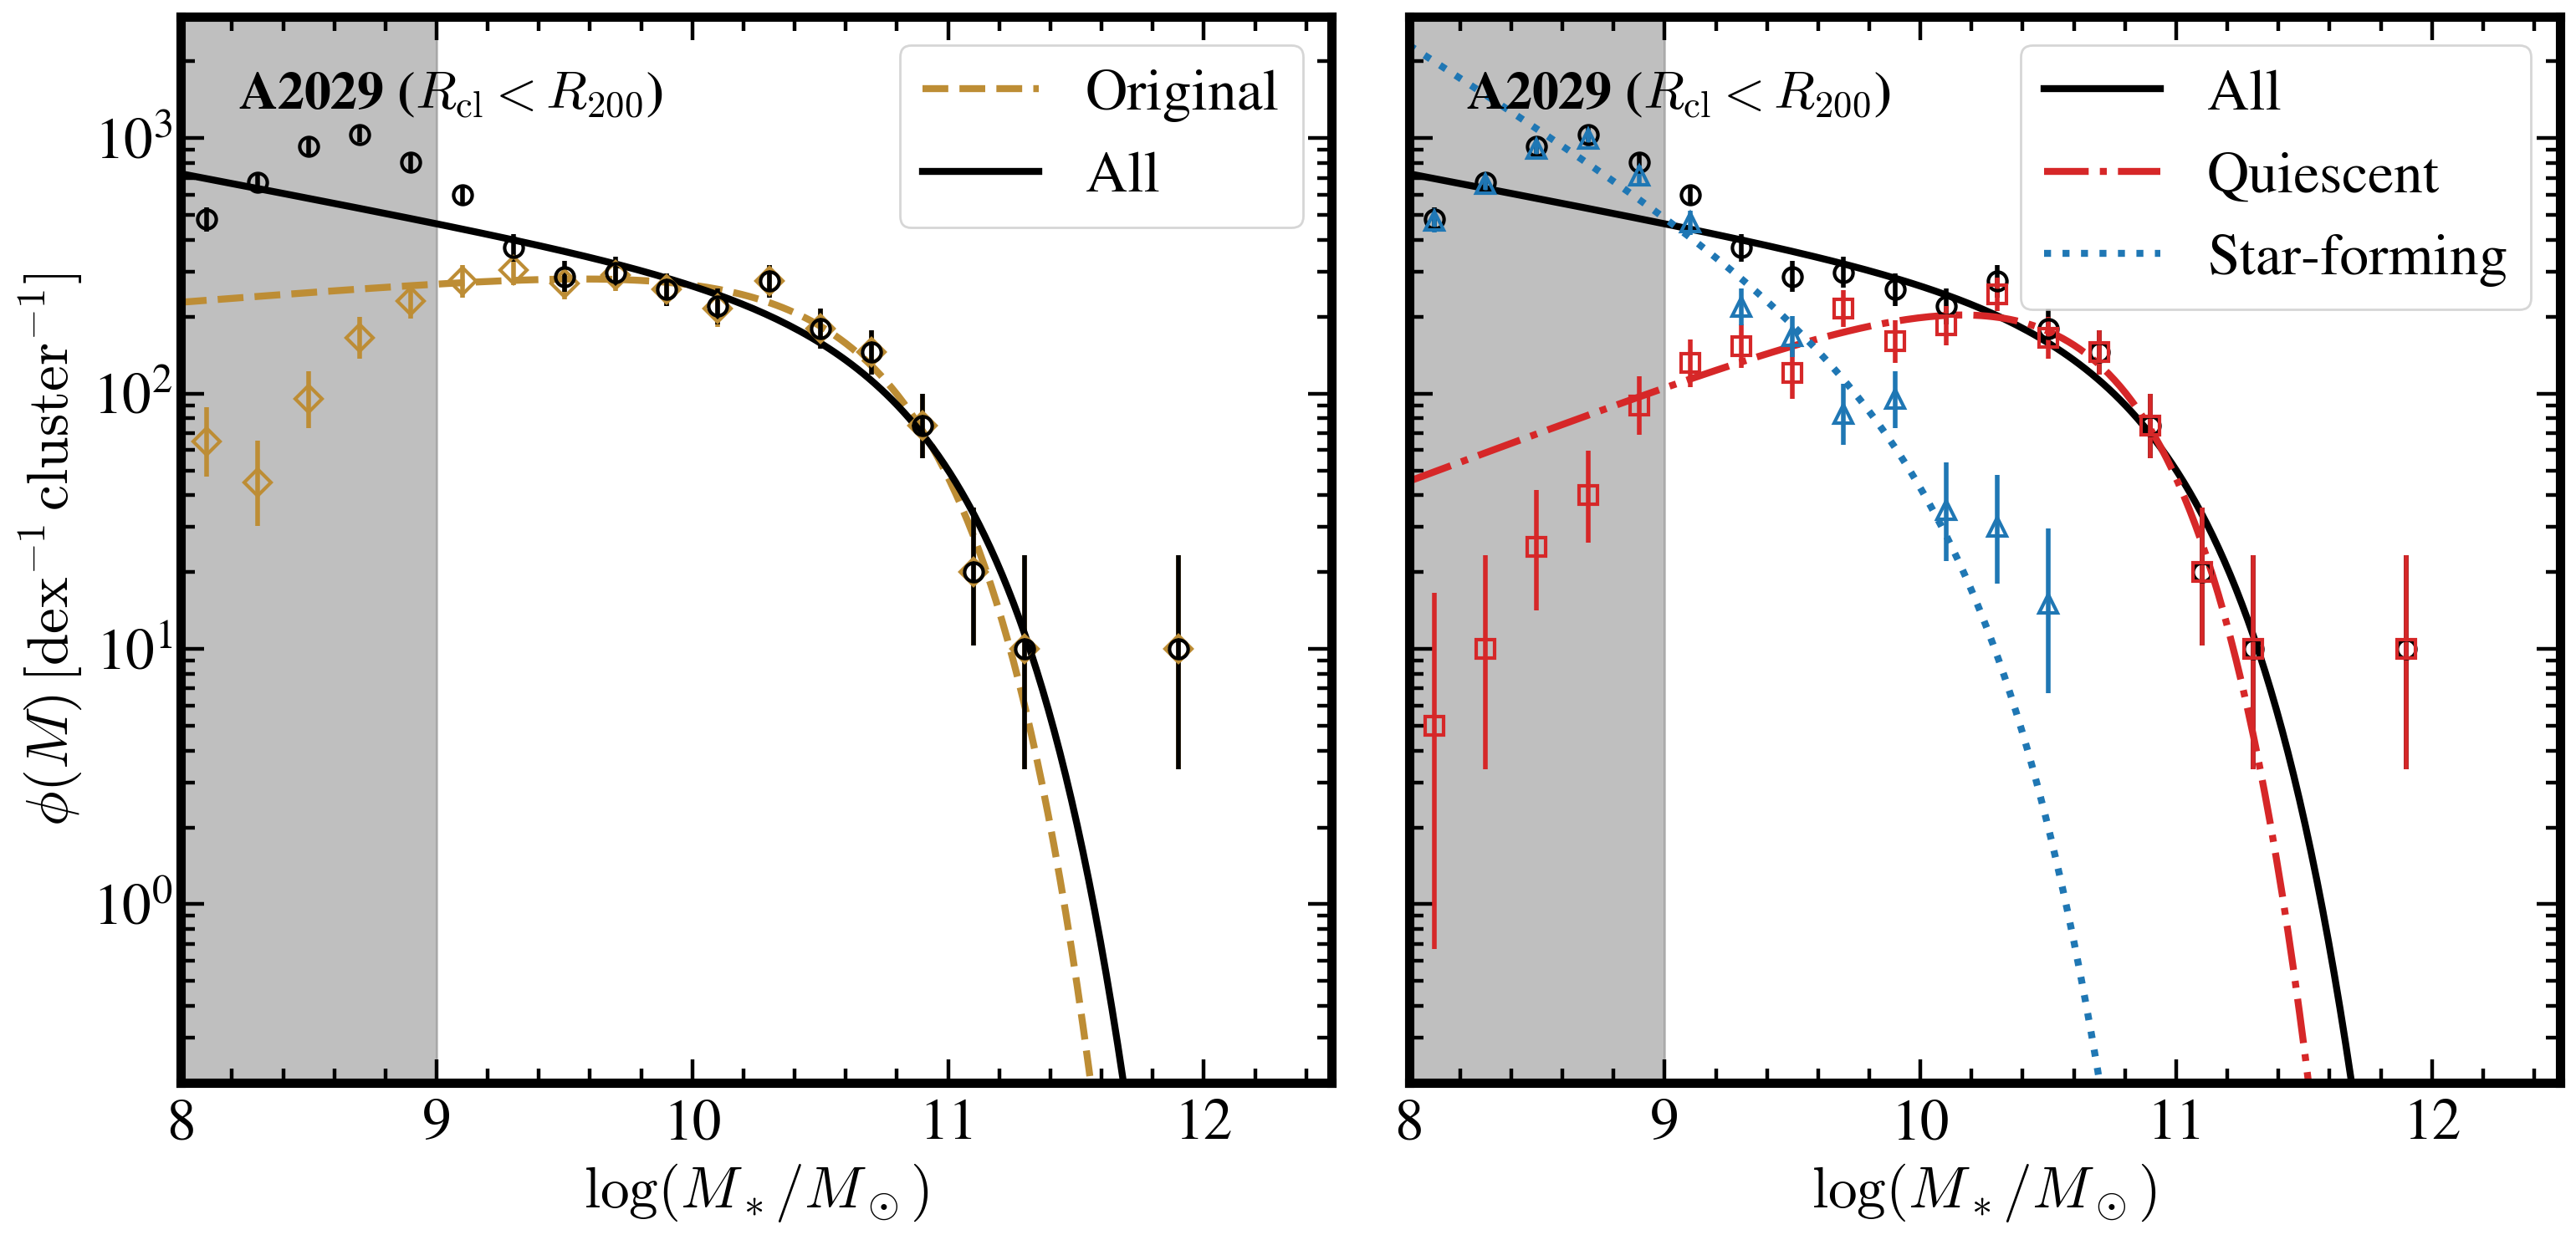

In [16]:
# --- 2) Plot using pre-computed fits ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
for idx, labels in panels.items():
    ax = axes[idx]
    # shade region below completeness limit
    ax.axvspan(8, SMF_complimit, color='gray', alpha=0.5)
    for label in labels:
        hist      = datasets[label]
        hist_norm = hist / bin_width
        yerr_up   = (np.sqrt(hist + 0.75) + 1) / bin_width
        yerr_low  = np.sqrt(np.clip(hist - 0.25, 1e-10, None)) / bin_width

        # data points (hollow)
        ax.errorbar(
            bin_centers[hist > 0], hist_norm[hist > 0],
            yerr=[yerr_low[hist > 0], yerr_up[hist > 0]],
            fmt=marker_symbols[label],
            color=colors[label],
            markerfacecolor='none',
            markeredgecolor=colors[label],
            markersize=8,
            markeredgewidth=1.5,
            ecolor=colors[label],
            capsize=0
        )

        # best-fit curve over full mass range
        phi0, Mstar, alpha = fit_results[label][0]
        M_fit = np.linspace(8, 12.5, 200)
        ax.plot(
            M_fit,
            schechter_1D_SMF(M_fit, phi0, Mstar, alpha),
            color=colors[label],
            lw=3,
            linestyle=line_styles[label],
            label=label
        )

    # styling
    ax.set_yscale('log')
    ax.set_xlim(8, 12.5)
    ax.set_ylim(0.2, 3000)
    ax.set_xlabel(r'$\log(M_*/M_\odot)$')
    if idx == 0:
        ax.set_ylabel(r'$\phi(M)\,[\mathrm{dex}^{-1}\,\mathrm{cluster}^{-1}]$')
    ax.legend()
    
    # Add annotations for MACH (top-left) and parameter values (bottom-left)
    ax.text(0.05, 0.95, rf'{TARGET} ($R_\mathrm{{cl}}<R_{{200}}$)', transform=ax.transAxes, fontsize=23, weight='bold', va='top', ha='left', color='black')

plt.tight_layout()
plt.show()

# 2. All clusters

In [17]:
import emcee
from scipy import stats
from tqdm import tqdm

# =============================================================
# Configuration (shared across all clusters)
# =============================================================
iterations    = 1000
bin_min, bin_max, bin_width = 7, 13, 0.2
bins          = np.arange(bin_min, bin_max + bin_width, bin_width)
bin_centers   = bins[:-1] + bin_width / 2

abs_mag_r_bins = np.arange(-30, 10, 1.00)
gr_bins        = np.arange(-6.5, 15.25, 0.25)
rcl_r200_bins  = np.arange(0, 1.2, 0.20)

# MCMC hyperparameters
ndim, nwalkers, burn_steps, prod_steps = 3, 256, 100, 500

initial_guesses = {
    'All':          np.array([333, 10.65, -1.00]),
    'Quiescent':    np.array([200, 10.70, -1.00]),
    'Star-forming': np.array([400, 10.60, -1.40]),
    'Original':     np.array([150, 10.50, -1.00]),
}

# =============================================================
# Load correction table once (shared for all clusters)
# =============================================================
bin_keys = ['Mr_bin', 'color_bin', 'Rcl_bin']
df_correction = pd.read_csv('./MACH_SMF_fspec_fmem_bin.csv')
for _k in bin_keys:
    df_correction[_k] = df_correction[_k].astype(str).str.strip()

# =============================================================
# Helper functions
# =============================================================
def _iv_to_str(iv):
    return np.nan if pd.isna(iv) else f"({iv.left}, {iv.right}]"

def _compute_ncor(group):
    Nphot  = len(group)
    Nspec  = (group['Z_TOT_Z'] != -99.0).sum()
    Nnon   = Nphot - Nspec
    f_mem  = group['f_mem'].iat[0]
    f_spec = group['f_spec'].iat[0]
    if pd.isna(f_mem):  f_mem  = 0.0
    if pd.isna(f_spec): f_spec = 0.0
    return pd.Series({'Nphot': Nphot, 'Nspec': Nspec, 'Nnon': Nnon,
                      'f_mem': f_mem, 'f_spec': f_spec,
                      'N_cor': int(round(Nnon * f_mem))})

def schechter_1D_SMF(M, phi_0, M_star, alpha):
    x = M - M_star
    return np.log(10) * phi_0 * 10**((1 + alpha) * x) * np.exp(-10**x)

def log_prior(theta):
    phi_0, M_star, alpha = theta
    if 0 < phi_0 < 1e4 and 8 < M_star < 14 and -5 < alpha < 5:
        return 0.0
    return -np.inf

def log_likelihood(theta, x, y, yerr):
    model = schechter_1D_SMF(x, *theta)
    return -0.5 * np.sum((y - model)**2 / yerr**2 + np.log(2 * np.pi * yerr**2))

def log_posterior(theta, x, y, yerr):
    lp = log_prior(theta)
    return lp + log_likelihood(theta, x, y, yerr) if np.isfinite(lp) else -np.inf

def fit_schechter_mcmc(x, y, yerr, initial):
    pos     = initial + 1e-4 * np.random.randn(nwalkers, ndim)
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(x, y, yerr))
    sampler.run_mcmc(pos, burn_steps, progress=False)
    sampler.reset()
    sampler.run_mcmc(None, prod_steps, progress=False)
    p16, p50, p84 = np.percentile(sampler.get_chain(flat=True), [16, 50, 84], axis=0)
    return p50, p50 - p16, p84 - p50

# =============================================================
# Per-cluster SMF pipeline
# =============================================================
def run_smf_pipeline(target, df, df_correction):
    """Run the full SMF pipeline for a single cluster TARGET."""

    # Step 1 – Prepare catalogue
    defn = df[df['CLID'] == target].copy()
    defn = defn[
        (defn['cmodelMag_g'] != -9999.0) &
        (defn['cmodelMag_r'] != -9999.0)
    ].copy()

    # Step 2 – g-r colour and 3D bin assignment
    defn['g_r']       = defn['cmodelMag_g_0'] - defn['cmodelMag_r_0']
    defn['Mr_bin']    = pd.cut(defn['AbsMag_r'], bins=abs_mag_r_bins).apply(_iv_to_str)
    defn['color_bin'] = pd.cut(defn['g_r'],      bins=gr_bins       ).apply(_iv_to_str)
    defn['Rcl_bin']   = pd.cut(defn['Rcl/R200'], bins=rcl_r200_bins ).apply(_iv_to_str)

    # Step 3 – DN4000_predicted
    train_mask = defn['Z_TOT_DN4000'] != -99.0
    slope, intercept, r_val, *_ = stats.linregress(
        defn.loc[train_mask, 'g_r'], defn.loc[train_mask, 'Z_TOT_DN4000']
    )
    defn['DN4000_predicted'] = np.where(
        train_mask, defn['Z_TOT_DN4000'],
        intercept + slope * defn['g_r']
    )

    # Step 4 – Attach f_mem / f_spec
    defn = defn.merge(df_correction[bin_keys + ['f_mem', 'f_spec']], on=bin_keys, how='left')

    # Step 5 – Compute N_cor per bin
    bin_stats = (
        defn.groupby(bin_keys, observed=True)
            .apply(_compute_ncor, include_groups=False)
            .reset_index()
    )
    defn = defn.merge(bin_stats[bin_keys + ['N_cor']], on=bin_keys, how='left')
    defn['N_cor'] = defn['N_cor'].fillna(0).astype(int)
    ncor_lookup = {tuple(r[bin_keys]): int(r['N_cor']) for _, r in bin_stats.iterrows()}

    # Step 6 – Spec members and non-spec pool
    member_y = defn[defn['MEMBER'] == 'Y'].copy()
    Nmem_raw = len(member_y)
    nonspec_pool = defn[(defn['Z_TOT_Z'] == -99.0) & (defn['MEMBER'] == 'N')]
    nonspec_grouped = {
        key: grp.reset_index(drop=True)
        for key, grp in nonspec_pool.groupby(bin_keys, observed=True)
    }

    # Step 7 – Monte Carlo
    hist_corrected, hist_quenched, hist_sf = [], [], []
    original_counts, _ = np.histogram(member_y['M_MASS_CIGALE_PARK'], bins=bins)
    original_counts = original_counts.astype(float)

    for _ in range(iterations):
        frames = []
        for bk, grp in nonspec_grouped.items():
            n_cor = ncor_lookup.get(bk, 0)
            if n_cor > 0:
                frames.append(grp.sample(n=min(n_cor, len(grp)), replace=False))
        final = pd.concat([member_y] + frames, ignore_index=True) if frames else member_y.copy()

        c_all, _ = np.histogram(final['M_MASS_CIGALE_PARK'], bins=bins)
        hist_corrected.append(c_all.astype(float))
        q  = final[final['DN4000_predicted'] >  1.5]
        sf = final[final['DN4000_predicted'] <= 1.5]
        c_q,  _ = np.histogram(q ['M_MASS_CIGALE_PARK'], bins=bins)
        c_sf, _ = np.histogram(sf['M_MASS_CIGALE_PARK'], bins=bins)
        hist_quenched.append(c_q .astype(float))
        hist_sf.append      (c_sf.astype(float))

    # Step 8 – Mean histograms
    mean_all = np.mean(hist_corrected, axis=0)
    mean_q   = np.mean(hist_quenched,  axis=0)
    mean_sf  = np.mean(hist_sf,        axis=0)

    # Step 9 – Completeness limit
    excess = np.clip(mean_all - original_counts, 0, None)
    cum_ex = np.cumsum(excess[::-1])[::-1]
    idx    = np.where(cum_ex >= 0.1 * Nmem_raw)[0][-1] if np.any(cum_ex >= 0.1 * Nmem_raw) else 0
    complimit = round(bin_centers[idx] - 0.5 * bin_width, 3)

    # Step 10 – Schechter MCMC fits
    datasets = {'Original': original_counts, 'All': mean_all,
                'Quiescent': mean_q, 'Star-forming': mean_sf}
    fit_labels  = list(datasets.keys())
    fit_median, fit_lower, fit_upper = [], [], []
    for lbl in fit_labels:
        h      = datasets[lbl]
        hn     = h / bin_width
        yerr   = (np.sqrt(h + 0.75) + 1) / bin_width
        mask   = (bin_centers > complimit) & (hn > 0)
        med, lo, hi = fit_schechter_mcmc(
            bin_centers[mask], hn[mask], yerr[mask], initial_guesses[lbl]
        )
        fit_median.append(med)
        fit_lower.append(lo)
        fit_upper.append(hi)
        print(f"  [{target}] {lbl:>13s}:  φ₀={med[0]:.1f}  M*={med[1]:.3f}  α={med[2]:.3f}")

    return {
        'original_counts': original_counts,
        'mean_all':         mean_all,
        'mean_quenched':    mean_q,
        'mean_sf':          mean_sf,
        'complimit':        complimit,
        'fit_labels':       np.array(fit_labels, dtype=object),
        'fit_median':       np.array(fit_median),
        'fit_lower':        np.array(fit_lower),
        'fit_upper':        np.array(fit_upper),
    }

# =============================================================
# Run for all clusters and save each result to separate file
# =============================================================

# Ensure output directory exists
output_dir = './SMF_results'
os.makedirs(output_dir, exist_ok=True)

for target in MACHLIST:
    print(f"\n=== Processing {target} ===")
    result = run_smf_pipeline(target, df, df_correction)
    # Prepare save dict as flat for np.savez
    save_dict = {'bin_centers': bin_centers}
    for field, val in result.items():
        save_dict[field] = val
    outpath = os.path.join(output_dir, f"{target}_single_results.npz")
    np.savez(outpath, **save_dict)
    print(f"Saved: {outpath}")


=== Processing A2245 ===
  [A2245]      Original:  φ₀=50.1  M*=10.981  α=-1.041
  [A2245]           All:  φ₀=20.7  M*=11.313  α=-1.314
  [A2245]     Quiescent:  φ₀=69.1  M*=10.834  α=-0.602
  [A2245]  Star-forming:  φ₀=107.5  M*=10.234  α=-0.980
Saved: ./SMF_results/A2245_single_results.npz

=== Processing A1767 ===
  [A1767]      Original:  φ₀=114.0  M*=10.473  α=-0.798
  [A1767]           All:  φ₀=72.1  M*=10.657  α=-1.056
  [A1767]     Quiescent:  φ₀=150.8  M*=10.237  α=-0.216
  [A1767]  Star-forming:  φ₀=205.3  M*=11.424  α=-0.595
Saved: ./SMF_results/A1767_single_results.npz

=== Processing A2244 ===
  [A2244]      Original:  φ₀=132.9  M*=10.624  α=-0.815
  [A2244]           All:  φ₀=63.7  M*=10.912  α=-1.182
  [A2244]     Quiescent:  φ₀=107.0  M*=10.646  α=-0.839
  [A2244]  Star-forming:  φ₀=200.6  M*=9.688  α=-0.693
Saved: ./SMF_results/A2244_single_results.npz

=== Processing A1831 ===
  [A1831]      Original:  φ₀=77.0  M*=10.672  α=-0.941
  [A1831]           All:  φ₀=27.5  M*

## Per-cluster figures (Figure 10)

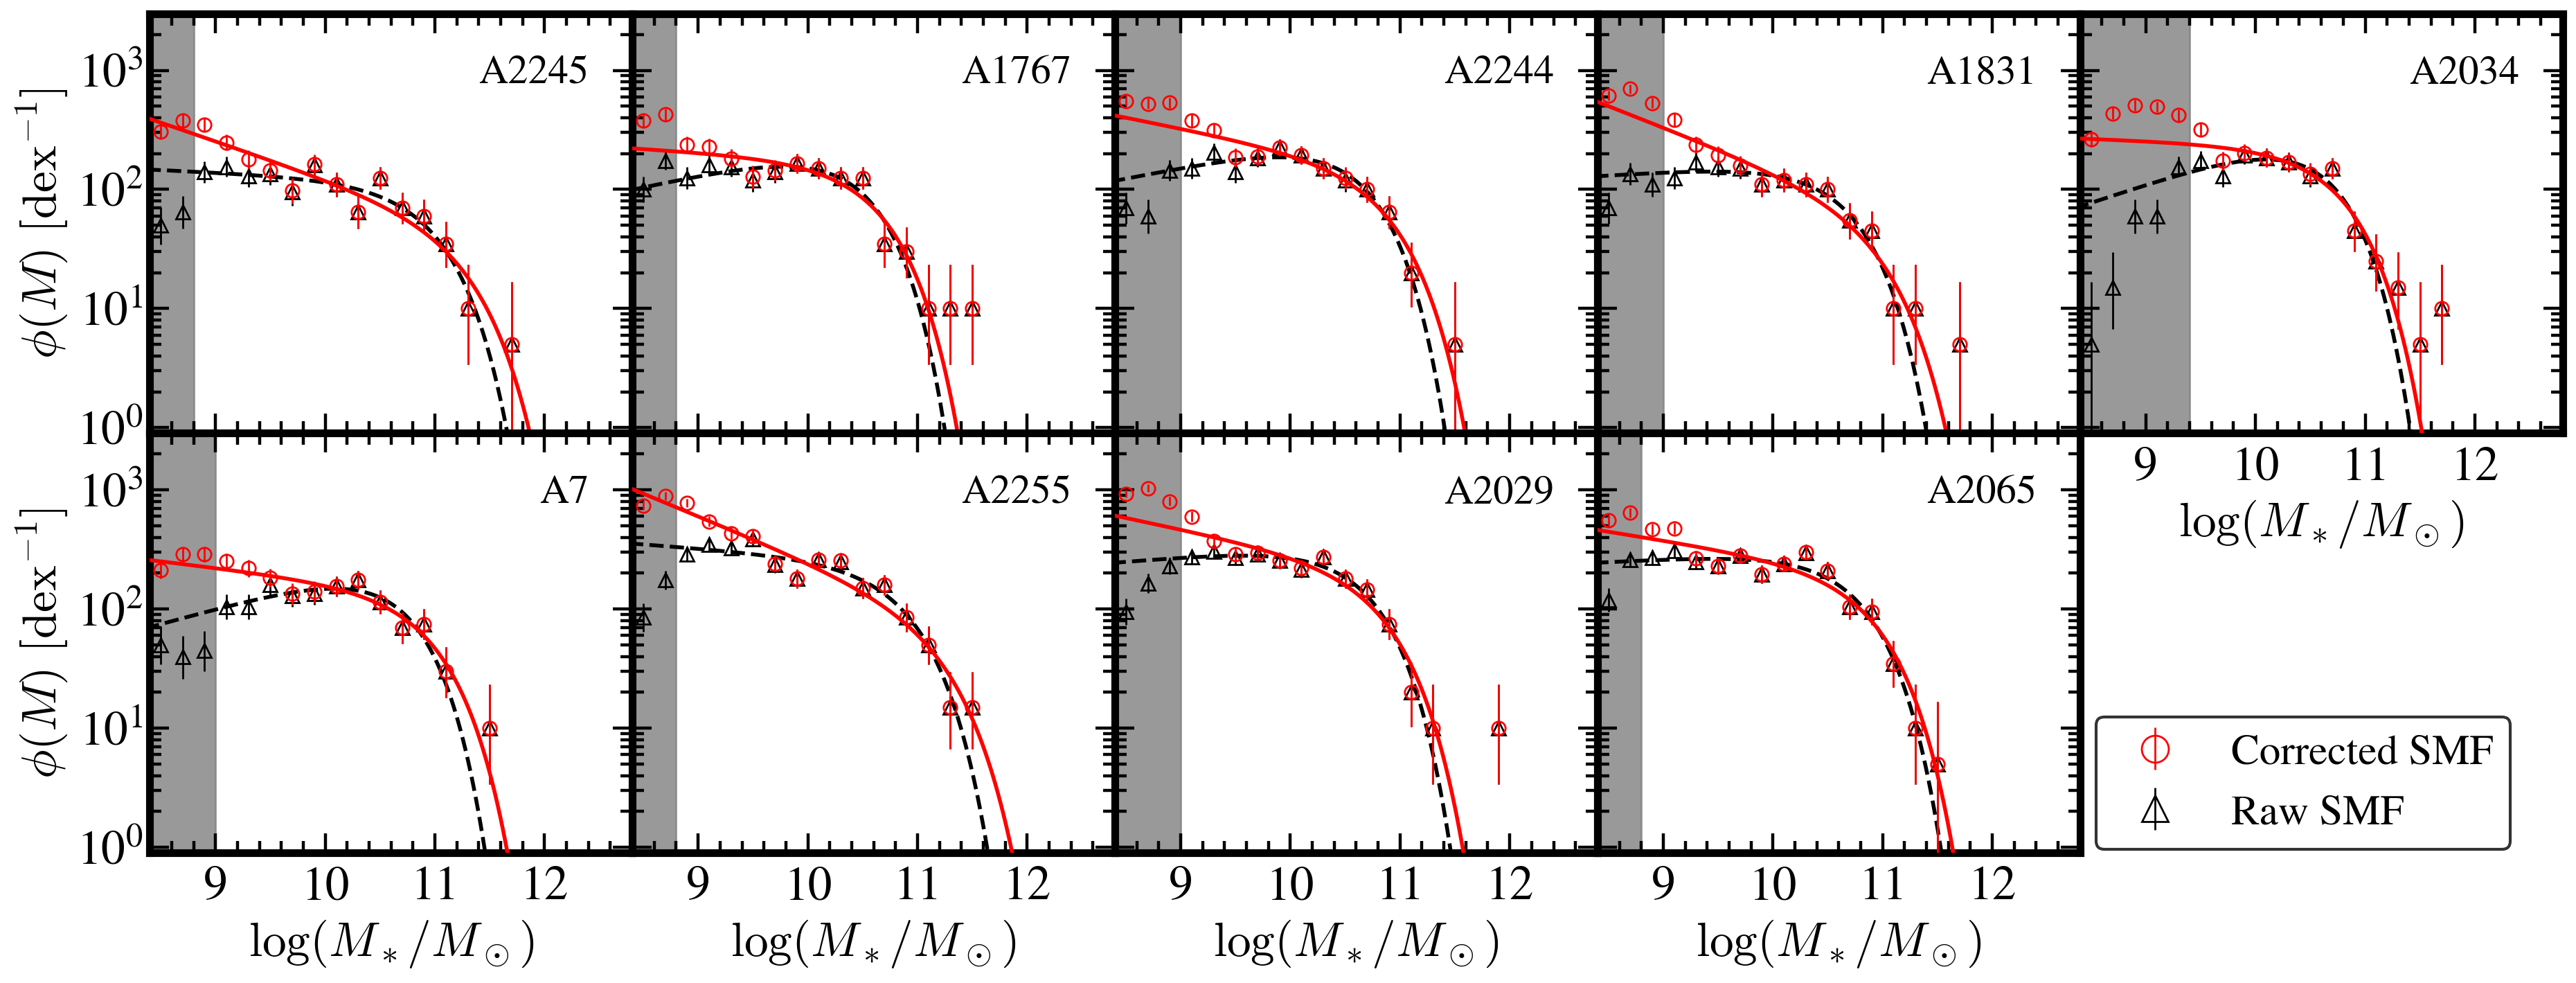

In [18]:
# =============================================================
# Load helper (reused by the later notebooks)
# =============================================================
def load_single_results_cluster(target, path_dir='./SMF_results'):
    """Load .npz for one cluster; returns same dict as run_smf_pipeline."""
    path = os.path.join(path_dir, f"{target}_single_results.npz")
    d    = np.load(path, allow_pickle=True)
    res  = {key: d[key] for key in d.files if key != 'bin_centers'}
    res['bin_centers'] = d['bin_centers']
    labels = list(res['fit_labels'])
    res['fit_results'] = {
        lbl: (res['fit_median'][i], res['fit_lower'][i], res['fit_upper'][i])
        for i, lbl in enumerate(labels)
    }
    return res

# =============================================================
# Schechter function
# =============================================================
def schechter_1D_SMF(M, phi_0, M_star, alpha):
    x = M - M_star
    return np.log(10) * phi_0 * 10**((1 + alpha) * x) * np.exp(-10**x)

# =============================================================
# Load all clusters from ./SMF_results/
# =============================================================
results = {target: load_single_results_cluster(target, path_dir='./SMF_results')
           for target in MACHLIST}

# =============================================================
# Multi-panel plot: 2 rows × 5 cols
# =============================================================
clusters = list(results.keys())
n_plots  = len(clusters)
nrows, ncols = 2, 5
M_fit = np.linspace(8, 12.5, 200)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(20, 8),
    sharey=True,
    gridspec_kw={'wspace': 0, 'hspace': 0}
)
axes_flat = axes.flatten()

for i, target in enumerate(clusters):
    ax   = axes_flat[i]
    data = results[target]

    x         = data['bin_centers']
    bin_width = float(x[1] - x[0])
    complim   = float(data['complimit'])

    # Normalised number-density histograms  [dex⁻¹]
    h_all  = data['mean_all']
    h_orig = data['original_counts']
    phi_all  = h_all  / bin_width
    phi_orig = h_orig / bin_width

    # Gehrels (1986) Poisson error bars
    yerr_up_all   = (np.sqrt(h_all  + 0.75) + 1) / bin_width
    yerr_lo_all   = np.sqrt(np.clip(h_all  - 0.25, 0.25, None)) / bin_width
    yerr_up_orig  = (np.sqrt(h_orig + 0.75) + 1) / bin_width
    yerr_lo_orig  = np.sqrt(np.clip(h_orig - 0.25, 0.25, None)) / bin_width

    mask_all  = h_all  > 0
    mask_orig = h_orig > 0

    # --- shade incomplete region ---
    ax.axvspan(x.min(), complim, color='gray', alpha=0.8, zorder=0)

    # --- corrected SMF: data points ---
    ax.errorbar(
        x[mask_all], phi_all[mask_all],
        yerr=[yerr_lo_all[mask_all], yerr_up_all[mask_all]],
        fmt='o', ms=7,
        color='red', markerfacecolor='none',
        capsize=0, elinewidth=1, zorder=4,
        label='Corrected SMF'
    )
    # --- corrected SMF: Schechter fit ---
    phi0_all, Mstar_all, alpha_all = data['fit_results']['All'][0]
    ax.plot(
        M_fit, schechter_1D_SMF(M_fit, phi0_all, Mstar_all, alpha_all),
        linestyle='-', color='red', linewidth=2, zorder=4
    )

    # --- raw (original) SMF: data points ---
    ax.errorbar(
        x[mask_orig], phi_orig[mask_orig],
        yerr=[yerr_lo_orig[mask_orig], yerr_up_orig[mask_orig]],
        fmt='^', ms=7,
        color='black', markerfacecolor='none',
        capsize=0, elinewidth=1, zorder=3,
        label='Raw SMF'
    )
    # --- raw SMF: Schechter fit ---
    phi0_o, Mstar_o, alpha_o = data['fit_results']['Original'][0]
    ax.plot(
        M_fit, schechter_1D_SMF(M_fit, phi0_o, Mstar_o, alpha_o),
        linestyle='--', color='black', linewidth=2, zorder=3
    )

    # --- cluster name annotation ---
    ax.text(0.91, 0.9, target,
            transform=ax.transAxes, fontsize=21, weight='normal',
            va='top', ha='right', color='black', zorder=5)

    # --- axes style ---
    ax.set_yscale('log')
    ax.set_xlim(8.4, 12.8)
    ax.set_ylim(0.9, 3000)
    ax.set_xticks(np.arange(9, 13, 1))
    ax.set_xlabel(r'$\log(M_*/M_\odot)$')
    if i % ncols == 0:
        ax.set_ylabel(r'$\phi(M)\ \mathrm{[dex}^{-1}\mathrm{]}$')

# turn off any unused panels
for ax in axes_flat[n_plots:]:
    ax.axis('off')

# --- single shared legend ---
handles, labels = axes_flat[0].get_legend_handles_labels()
leg = fig.legend(
    handles, labels,
    bbox_to_anchor=(0.95, 0.16),
    loc='lower right',
    ncol=1, fontsize=22,
    markerscale=2,
    frameon=True, edgecolor='black'
)
leg.get_frame().set_linewidth(1.5)

plt.tight_layout(rect=[0.02, 0.02, 0.98, 0.98])
plt.savefig(f"{MAINPATH}/FIGURE/IMAGES/Figure10.pdf", format='pdf', bbox_inches='tight')
plt.show()

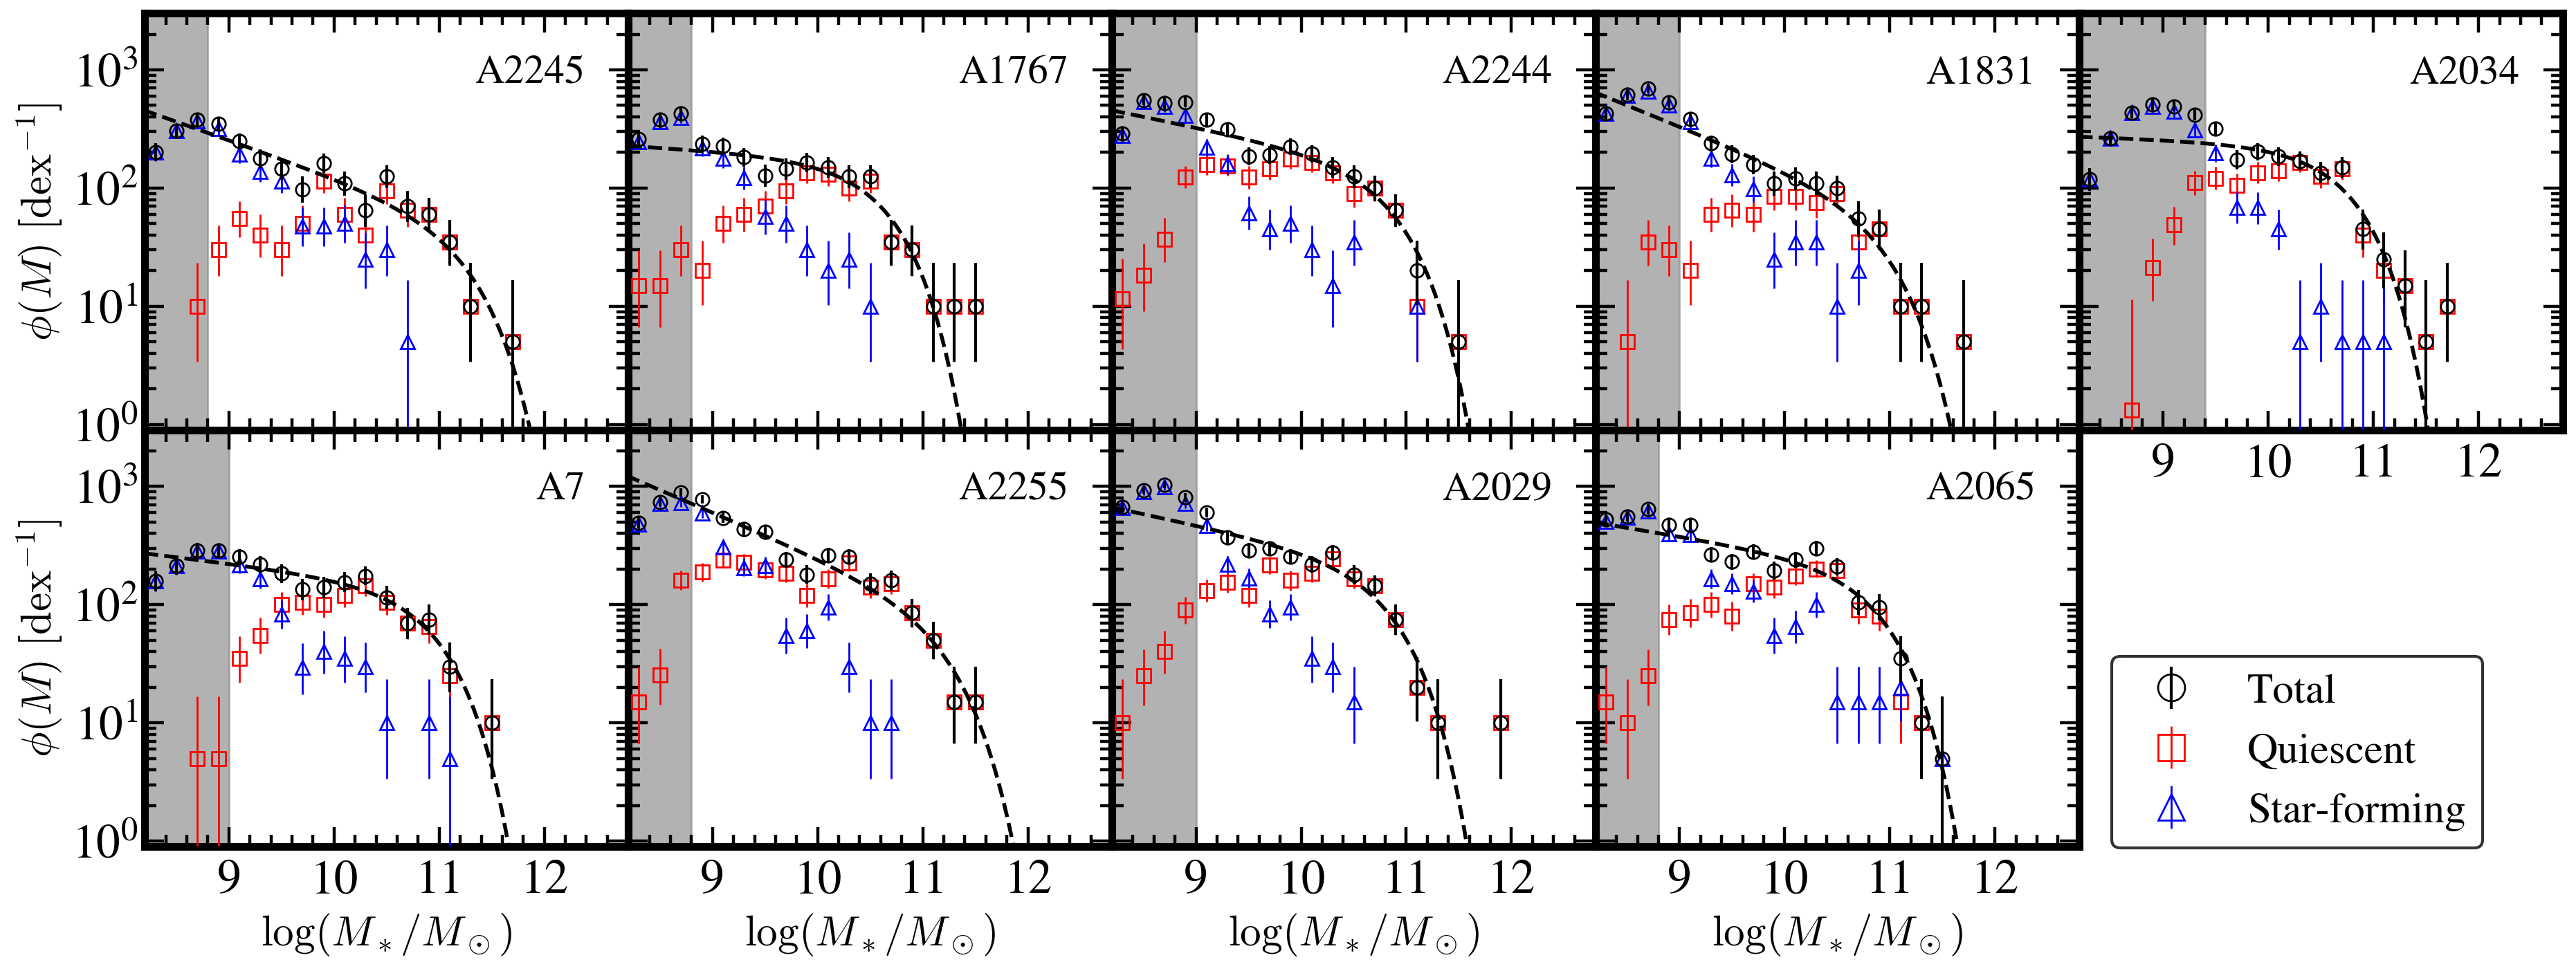

In [19]:
# =============================================================
# NOTE: assumes `results` is already loaded in the previous cell:
#   results = {target: load_single_results_cluster(target, './SMF_results')
#              for target in MACHLIST}
# =============================================================

def schechter_1D_SMF(M, phi_0, M_star, alpha):
    x = M - M_star
    return np.log(10) * phi_0 * 10**((1 + alpha) * x) * np.exp(-10**x)

# =============================================================
# Multi-panel plot: 2 rows × 5 cols
# =============================================================
nrows, ncols = 2, 5
M_fit = np.linspace(8, 12.5, 200)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(20, 8),
    sharey=True,
    gridspec_kw={'wspace': 0, 'hspace': 0}
)
axes_flat = axes.flatten()

for i, target in enumerate(MACHLIST):
    ax   = axes_flat[i]
    data = results[target]

    x         = data['bin_centers']
    bin_width = float(x[1] - x[0])
    complimit = float(data['complimit'])

    # --- Normalised number densities  [dex⁻¹] ---
    h_all = data['mean_all']
    h_q   = data['mean_quenched']
    h_sf  = data['mean_sf']

    phi_all = h_all / bin_width
    phi_q   = h_q   / bin_width
    phi_sf  = h_sf  / bin_width

    # --- Gehrels (1986) asymmetric Poisson errors ---
    def gehrels_errors(h):
        up = (np.sqrt(h + 0.75) + 1) / bin_width
        lo = np.sqrt(np.clip(h - 0.25, 0.25, None)) / bin_width
        return lo, up

    lo_all, up_all = gehrels_errors(h_all)
    lo_q,   up_q   = gehrels_errors(h_q)
    lo_sf,  up_sf  = gehrels_errors(h_sf)

    mask_all = h_all > 0
    mask_q   = h_q   > 0
    mask_sf  = h_sf  > 0

    # --- shade incomplete region ---
    ax.axvspan(x.min(), complimit, color='gray', alpha=0.6, zorder=0)

    # --- total corrected SMF  (black circles) ---
    ax.errorbar(
        x[mask_all], phi_all[mask_all],
        yerr=[lo_all[mask_all], up_all[mask_all]],
        fmt='o', ms=7, color='black', markerfacecolor='none',
        capsize=0, elinewidth=1.5, zorder=5, label='Total'
    )
    phi0, Mstar, alpha_p = data['fit_results']['All'][0]
    ax.plot(M_fit, schechter_1D_SMF(M_fit, phi0, Mstar, alpha_p),
            ls='--', color='black', lw=2, zorder=5)

    # --- quenched SMF  (red squares) ---
    ax.errorbar(
        x[mask_q], phi_q[mask_q],
        yerr=[lo_q[mask_q], up_q[mask_q]],
        fmt='s', ms=7, color='red', markerfacecolor='none',
        capsize=0, elinewidth=1, zorder=3, label='Quiescent'
    )
    # phi0_q, Mstar_q, alpha_q = data['fit_results']['Quiescent'][0]
    # ax.plot(M_fit, schechter_1D_SMF(M_fit, phi0_q, Mstar_q, alpha_q),
    #         ls='-', color='red', lw=2, zorder=3)

    # --- star-forming SMF  (blue triangles) ---
    ax.errorbar(
        x[mask_sf], phi_sf[mask_sf],
        yerr=[lo_sf[mask_sf], up_sf[mask_sf]],
        fmt='^', ms=7, color='blue', markerfacecolor='none',
        capsize=0, elinewidth=1, zorder=4, label='Star-forming'
    )
    # phi0_sf, Mstar_sf, alpha_sf = data['fit_results']['Star-forming'][0]
    # ax.plot(M_fit, schechter_1D_SMF(M_fit, phi0_sf, Mstar_sf, alpha_sf),
    #         ls='-', color='blue', lw=2, zorder=4)

    # --- cluster name ---
    ax.text(0.91, 0.90, target,
            transform=ax.transAxes, fontsize=21,
            va='top', ha='right', color='black', zorder=6)

    # --- axes style ---
    ax.set_yscale('log')
    ax.set_xlim(8.2, 12.8)
    ax.set_ylim(0.9, 3000)
    ax.set_xticks(np.arange(9, 13, 1))

    if i % ncols == 0:
        ax.set_ylabel(r'$\phi(M)\ \mathrm{[dex}^{-1}\mathrm{]}$', fontsize=22)
    if i >= (nrows - 1) * ncols:
        ax.set_xlabel(r'$\log(M_*/M_\odot)$', fontsize=22)

# turn off unused panels
for ax in axes_flat[len(MACHLIST):]:
    ax.axis('off')

# --- single shared legend ---
handles, labels = axes_flat[0].get_legend_handles_labels()
leg = fig.legend(
    handles, labels,
    bbox_to_anchor=(0.95, 0.16), loc='lower right',
    ncol=1, fontsize=22, markerscale=2,
    frameon=True, edgecolor='black'
)
leg.get_frame().set_linewidth(1.5)

plt.tight_layout(rect=[0.03, 0.03, 0.99, 0.98])
# plt.savefig(f"{FIGUREPATH}/MACH_SMF_components.pdf", format='pdf', bbox_inches='tight')
plt.show()

## Machine-readable SMF table (Table 4)

In [20]:
from functools import reduce

# =============================================================
# Build a per-cluster SMF table with Poisson errors
#
# For each cluster we compute number-density Φ(M) = counts / bin_width
# and a simple Poisson error σ = √counts / bin_width.
# We store both raw (spec-only) and completeness-corrected values.
# =============================================================

table_list = []
for target in MACHLIST:
    data = results[target]
    x         = data['bin_centers']
    bin_width = float(x[1] - x[0])

    h_corr = data['mean_all']           # completeness-corrected counts
    h_raw  = data['original_counts']    # spec-member-only counts

    # Number-density Φ [dex⁻¹ cluster⁻¹]
    phi_corr = h_corr / bin_width
    phi_raw  = h_raw  / bin_width

    # Simple Poisson uncertainty: σ = √N / bin_width
    err_corr = np.sqrt(h_corr) / bin_width
    err_raw  = np.sqrt(h_raw)  / bin_width

    table_list.append(pd.DataFrame({
        'M_bin_center':       x,
        f'{target}_raw':      phi_raw,
        f'{target}_raw_err':  err_raw,
        f'{target}_corr':     phi_corr,
        f'{target}_corr_err': err_corr,
    }))

# Merge all per-cluster tables on the shared mass-bin column
table_all = reduce(
    lambda left, right: pd.merge(left, right, on='M_bin_center', how='outer'),
    table_list
)
table_all['M_bin_center'] = table_all['M_bin_center'].round(2)

# =============================================================
# Add human-readable "value ± error" formatted string columns
# (useful for quick inspection / CSV export)
# =============================================================
for target in MACHLIST:
    for kind in ['raw', 'corr']:
        val_col = f'{target}_{kind}'
        err_col = f'{target}_{kind}_err'
        table_all[f'{target}_{kind}_fmt'] = table_all.apply(
            lambda row, v=val_col, e=err_col:
                f"{row[v]:.1f} ± {row[e]:.1f}" if pd.notna(row[v]) else '',
            axis=1
        )

# =============================================================
# Define mask for complete mass bins (8.5 ≤ M_bin_center ≤ 12.5)
# =============================================================
mask_complete = (table_all['M_bin_center'] >= 8.5) & (table_all['M_bin_center'] <= 12.5)

# Sample preview: first four clusters, raw + corr
cols_sample = ['M_bin_center'] + [
    f'{t}_{k}_fmt'
    for t in ['A2245', 'A1767', 'A2244', 'A1831']
    for k in ['raw', 'corr']
]
# table_all.loc[mask_complete, cols_sample].to_csv('SMF_Table_sample.csv', index=False)     # optional CSV export

# Full table: all clusters
cols_all = ['M_bin_center'] + [
    f'{t}_{k}_fmt' for t in MACHLIST for k in ['raw', 'corr']
]
# table_all.loc[mask_complete, cols_all].to_csv('SMF_Table.csv', index=False)                # optional CSV export

# =============================================================
# Machine-readable table (MRT) for journal submission
#
# Fixed-width format following AAS/CDS byte-by-byte convention.
# Layout per row:
#   F4.1  M_bin_center
#   then for each cluster:  F6.1 raw  F5.1 raw_err  F6.1 corr  F5.1 corr_err
# =============================================================
header_txt = """\
Title: The Stellar Mass Function of Nine Massive Galaxy Clusters in the Local Universe
Authors: Jong-In Park, Jubee Sohn, Margaret J. Geller, Ken J. Rines, Antonaldo Diaferio
Table: SMFs for MACH Clusters

================================================================================
Byte-by-byte Description of file: Table4_MRT.txt
--------------------------------------------------------------------------------
   Bytes   Format  Units   Label              Explanations
--------------------------------------------------------------------------------
   1-  4   F4.1    ---     M_bin_center       Center of the stellar-mass bin
   6- 11   F6.1    ---     A2245_raw          Raw Phi for A2245
  13- 17   F5.1    ---     e_A2245_raw        Poisson uncertainty on A2245_raw
  19- 24   F6.1    ---     A2245_corr         Corrected Phi for A2245
  26- 30   F5.1    ---     e_A2245_corr       Poisson uncertainty on A2245_corr
  32- 37   F6.1    ---     A1767_raw          Raw Phi for A1767
  39- 43   F5.1    ---     e_A1767_raw        Poisson uncertainty on A1767_raw
  45- 50   F6.1    ---     A1767_corr         Corrected Phi for A1767
  52- 56   F5.1    ---     e_A1767_corr       Poisson uncertainty on A1767_corr
  58- 63   F6.1    ---     A2244_raw          Raw Phi for A2244
  65- 69   F5.1    ---     e_A2244_raw        Poisson uncertainty on A2244_raw
  71- 76   F6.1    ---     A2244_corr         Corrected Phi for A2244
  78- 82   F5.1    ---     e_A2244_corr       Poisson uncertainty on A2244_corr
  84- 89   F6.1    ---     A1831_raw          Raw Phi for A1831
  91- 95   F5.1    ---     e_A1831_raw        Poisson uncertainty on A1831_raw
  97-102   F6.1    ---     A1831_corr         Corrected Phi for A1831
 104-108   F5.1    ---     e_A1831_corr       Poisson uncertainty on A1831_corr
 110-115   F6.1    ---     A2034_raw          Raw Phi for A2034
 117-121   F5.1    ---     e_A2034_raw        Poisson uncertainty on A2034_raw
 123-128   F6.1    ---     A2034_corr         Corrected Phi for A2034
 130-134   F5.1    ---     e_A2034_corr       Poisson uncertainty on A2034_corr
 136-141   F6.1    ---     A7_raw             Raw Phi for A7
 143-147   F5.1    ---     e_A7_raw           Poisson uncertainty on A7_raw
 149-154   F6.1    ---     A7_corr            Corrected Phi for A7
 156-160   F5.1    ---     e_A7_corr          Poisson uncertainty on A7_corr
 162-167   F6.1    ---     A2255_raw          Raw Phi for A2255
 169-173   F5.1    ---     e_A2255_raw        Poisson uncertainty on A2255_raw
 175-180   F6.1    ---     A2255_corr         Corrected Phi for A2255
 182-186   F5.1    ---     e_A2255_corr       Poisson uncertainty on A2255_corr
 188-193   F6.1    ---     A2029_raw          Raw Phi for A2029
 195-199   F5.1    ---     e_A2029_raw        Poisson uncertainty on A2029_raw
 201-206   F6.1    ---     A2029_corr         Corrected Phi for A2029
 208-212   F5.1    ---     e_A2029_corr       Poisson uncertainty on A2029_corr
 214-219   F6.1    ---     A2065_raw          Raw Phi for A2065
 221-225   F5.1    ---     e_A2065_raw        Poisson uncertainty on A2065_raw
 227-232   F6.1    ---     A2065_corr         Corrected Phi for A2065
 234-238   F5.1    ---     e_A2065_corr       Poisson uncertainty on A2065_corr
--------------------------------------------------------------------------------
Note (1): All uncertainties are simple Poisson errors (σ = √N / Δbin).
================================================================================
"""

def _fmt(value, width, decimals):
    """Right-justify a float in a fixed-width field; blank if NaN."""
    if value is None or pd.isna(value):
        return ' ' * width
    return f"{float(value):.{decimals}f}".rjust(width)

output_mrt = 'Table4_MRT.txt'
with open(output_mrt, 'w', encoding='utf-8') as f:
    f.write(header_txt)
    for _, row in table_all.loc[mask_complete].iterrows():
        parts = [_fmt(row['M_bin_center'], 4, 1)]
        for cl in MACHLIST:
            parts += [
                ' ' + _fmt(row[f'{cl}_raw'],      6, 1),
                ' ' + _fmt(row[f'{cl}_raw_err'],  5, 1),
                ' ' + _fmt(row[f'{cl}_corr'],     6, 1),
                ' ' + _fmt(row[f'{cl}_corr_err'], 5, 1),
            ]
        f.write(''.join(parts) + '\n')

print(f"Saved: {output_mrt}")

Saved: Table4_MRT.txt


## Schechter fit parameters per cluster

In [21]:
# =============================================================
# Schechter fit-parameter summary table
#
# For each cluster we extract the MCMC posterior medians and
# asymmetric 1-σ errors (16th / 84th percentile) for both:
#   'Original'  → spec-member-only (raw) SMF
#   'All'       → completeness-corrected SMF
#
# Asymmetric errors are stored as separate lower / upper columns
# so nothing is lost; a symmetric mean error is also added for
# quick inspection.
# =============================================================

records = []
for cl in MACHLIST:
    fr = results[cl]['fit_results']

    for kind, label in [('Original', 'raw'), ('All', 'corr')]:
        med, lo, hi = fr[kind]          # each is a 3-element array (phi0, M*, alpha)
        records.append({
            'Cluster':  cl,
            'kind':     label,
            'phi0':     med[0],
            'phi0_lo':  lo[0],
            'phi0_hi':  hi[0],
            'Mstar':    med[1],
            'Mstar_lo': lo[1],
            'Mstar_hi': hi[1],
            'alpha':    med[2],
            'alpha_lo': lo[2],
            'alpha_hi': hi[2],
            'complimit': float(results[cl]['complimit']),
        })

df_fits = pd.DataFrame(records)

# Human-readable ± string columns (symmetric mean of lo/hi errors)
for param in ['phi0', 'Mstar', 'alpha']:
    df_fits[f'{param}_fmt'] = df_fits.apply(
        lambda r, p=param:
            f"{r[p]:.3f} +{r[f'{p}_hi']:.3f} / -{r[f'{p}_lo']:.3f}",
        axis=1
    )

# Wide format: one row per cluster, raw and corr side by side
df_wide = df_fits.pivot(index='Cluster', columns='kind',
                        values=['phi0_fmt', 'Mstar_fmt', 'alpha_fmt', 'complimit'])
df_wide.columns = ['_'.join(c) for c in df_wide.columns]
df_wide = df_wide.reset_index().reindex(
    ['Cluster',
     'phi0_fmt_raw',  'Mstar_fmt_raw',  'alpha_fmt_raw',
     'phi0_fmt_corr', 'Mstar_fmt_corr', 'alpha_fmt_corr',
     'complimit_corr'],
    axis=1
).rename(columns={'complimit_corr': 'complimit'})

# Preserve MACHLIST ordering
df_wide['Cluster'] = pd.Categorical(df_wide['Cluster'], categories=MACHLIST, ordered=True)
df_wide = df_wide.sort_values('Cluster').reset_index(drop=True)

# Save
out_csv = 'SMF_Fit_Params_Table.csv'
df_wide.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")
print(df_wide.to_string(index=False))

Saved: SMF_Fit_Params_Table.csv
Cluster              phi0_fmt_raw          Mstar_fmt_raw          alpha_fmt_raw            phi0_fmt_corr         Mstar_fmt_corr         alpha_fmt_corr complimit
  A2245  50.134 +19.438 / -15.594 10.981 +0.213 / -0.188 -1.041 +0.100 / -0.089 20.697 +24.216 / -10.039 11.313 +0.424 / -0.396 -1.314 +0.128 / -0.082       8.8
  A1767 113.990 +30.440 / -27.805 10.473 +0.140 / -0.128 -0.798 +0.124 / -0.116 72.099 +45.527 / -24.986 10.657 +0.211 / -0.219 -1.056 +0.174 / -0.118       8.8
  A2244 132.867 +32.993 / -29.271 10.624 +0.134 / -0.125 -0.815 +0.113 / -0.102 63.665 +31.053 / -22.345 10.912 +0.211 / -0.187 -1.182 +0.113 / -0.095       9.0
  A1831  76.962 +25.844 / -22.711 10.672 +0.174 / -0.159 -0.941 +0.126 / -0.118 27.504 +26.979 / -13.897 11.006 +0.348 / -0.337 -1.359 +0.140 / -0.103       9.0
  A2034 152.304 +40.453 / -39.972 10.600 +0.146 / -0.130 -0.688 +0.185 / -0.174 97.249 +49.822 / -36.190 10.783 +0.197 / -0.183 -1.033 +0.198 / -0.161       9.4
  

# 3. Corrected SMFs and literature clusters (Figure 11)

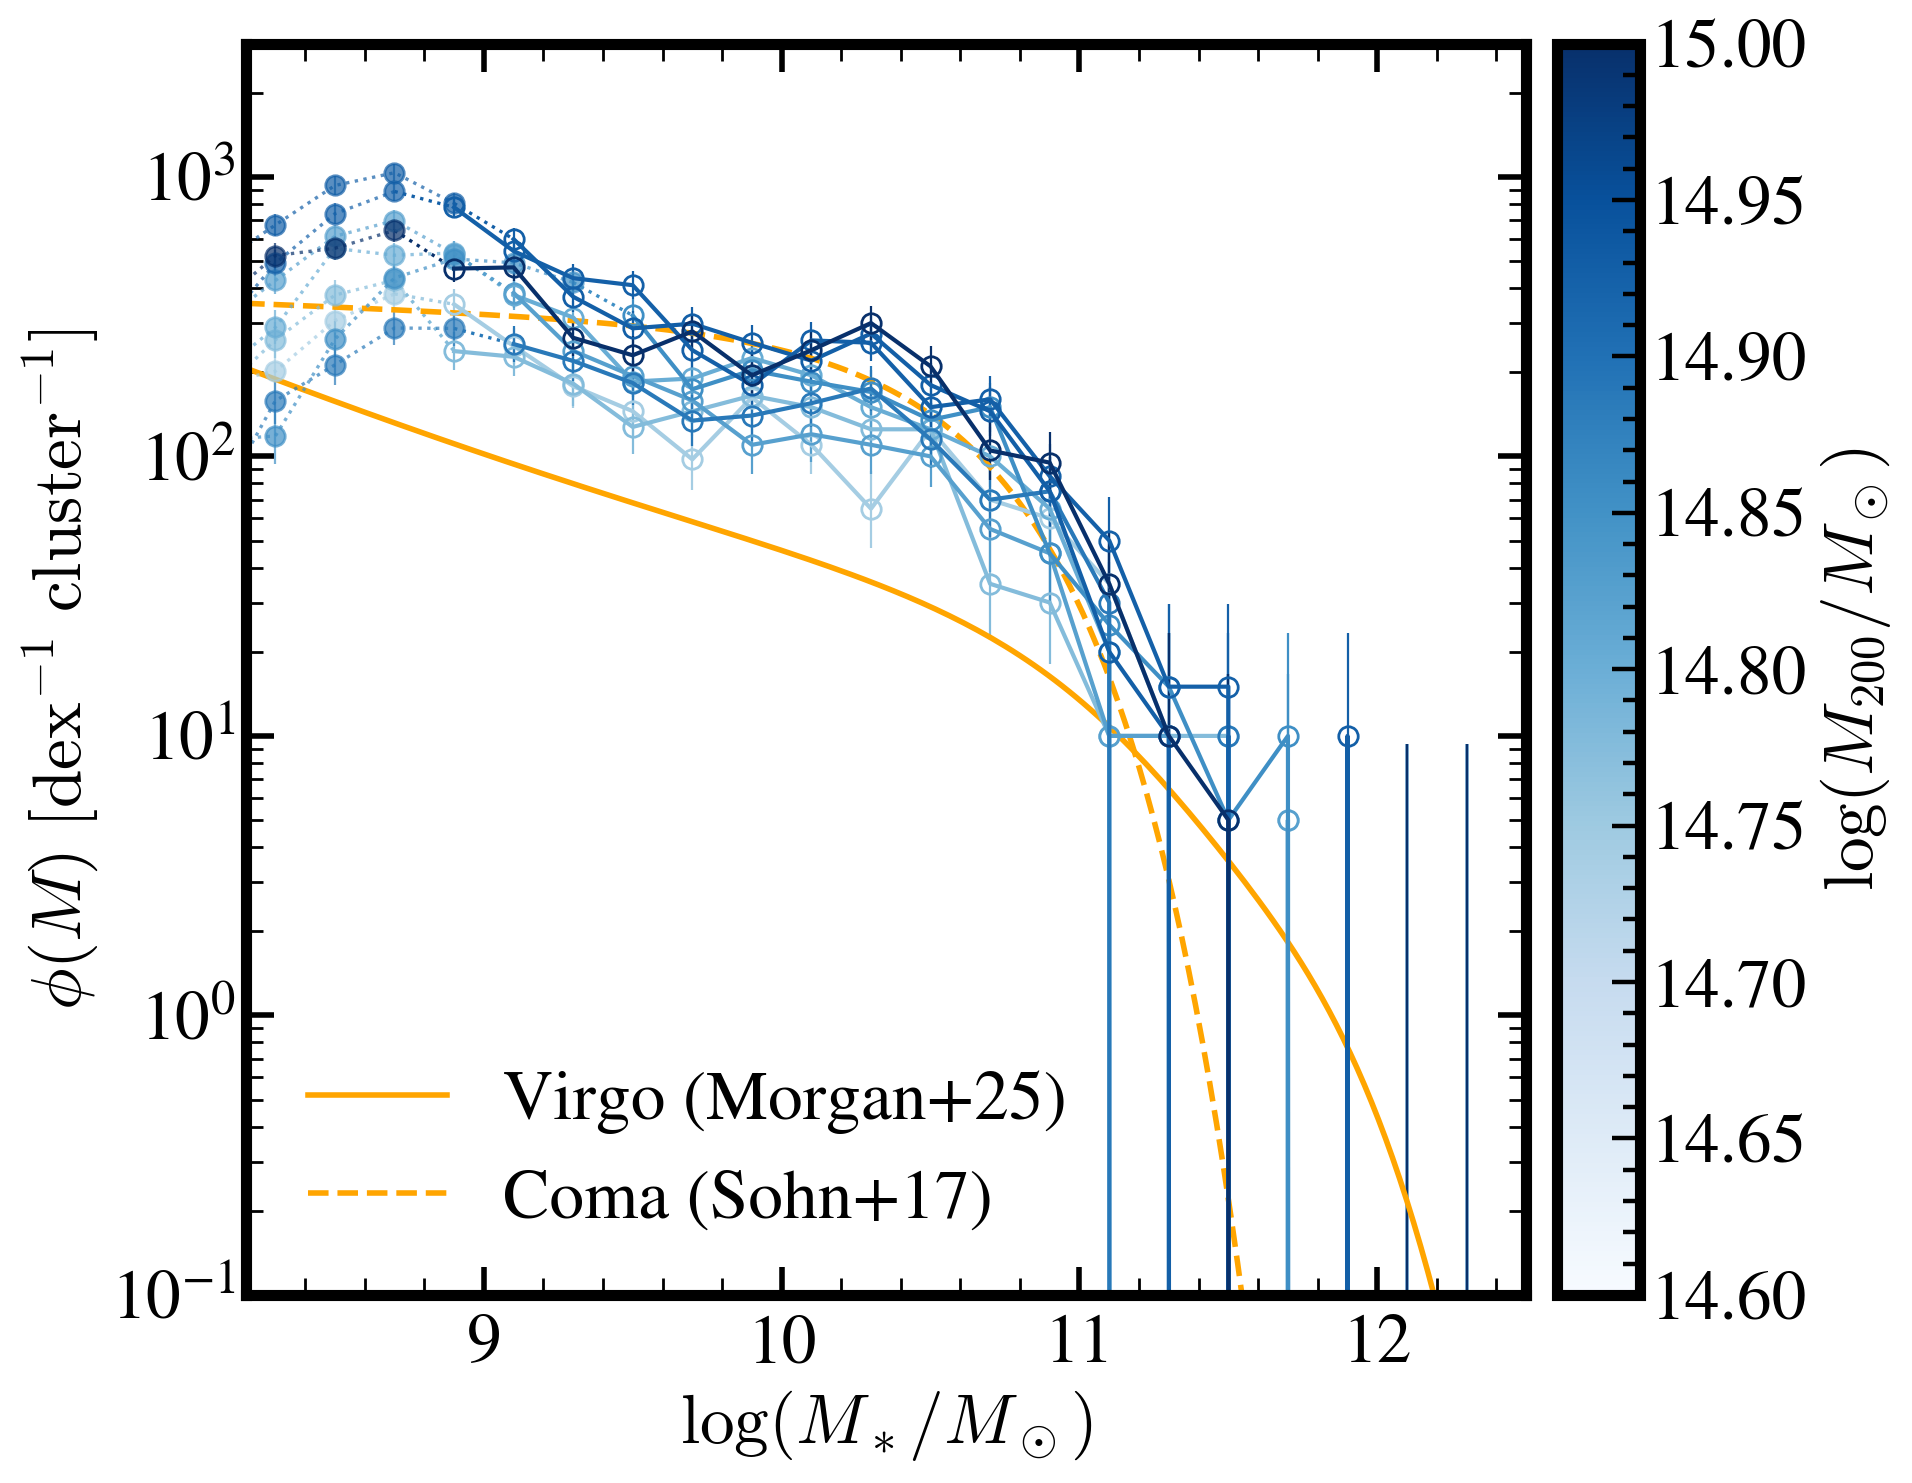

In [22]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# =============================================================
# Schechter function for SMF
# =============================================================
def schechter_1D_SMF(M, phi0, Mstar, alpha):
    x = M - Mstar
    return np.log(10) * phi0 * 10**((1 + alpha) * x) * np.exp(-10**x)

# =============================================================
# Reference literature SMFs
# =============================================================
virgo_pops = [
    {'phi0': 2.66, 'Mstar': 11.01, 'alpha': -1.42},   # Core: Quiescent
    {'phi0': 2.29, 'Mstar': 11.54, 'alpha': -1.03},   # Core: Low-SFR
    {'phi0': 1.61, 'Mstar': 10.78, 'alpha': -0.99},   # Core: SF
    {'phi0': 0.57, 'Mstar': 11.73, 'alpha': -1.51},   # Inner ring: Quiescent
    {'phi0': 1.89, 'Mstar': 11.02, 'alpha': -1.17},   # Inner ring: Low-SFR
    {'phi0': 3.24, 'Mstar': 10.89, 'alpha': -1.02},   # Inner ring: SF
]

coma_params    = (130, 10.65, -1.04)  # (phi0, Mstar, alpha)
coma_target_y  = 360.0                # the Coma curve is rescaled to phi = 360 at log M* = 8.0

# =============================================================
# Build DataFrame of all cluster SMF data points
# (bins below the completeness limit are drawn with filled circles)
# =============================================================
rows = []
for cl in MACHLIST:
    data = results[cl]
    x = data['bin_centers']
    bw = float(x[1] - x[0])
    h = data['mean_all']

    phi = h / bw
    err_lo = np.sqrt(np.clip(h - 0.25, 0.25, None)) / bw
    err_hi = (np.sqrt(h + 0.75) + 1) / bw
    complimit = float(data['complimit'])

    for xi, yi, lo, hi in zip(x, phi, err_lo, err_hi):
        rows.append({
            'TARGET': cl,
            'bin_center': xi,
            'phi': yi,
            'err_lo': lo,
            'err_hi': hi,
            'complimit': complimit,
        })

df_smf = pd.DataFrame(rows)

# =============================================================
# Colour-code clusters by log10(M200) [Blues colormap]
# =============================================================
norm = mcolors.Normalize(vmin=14.6, vmax=15.0)
cmap = cm.Blues

def cluster_color(cl):
    try:
        m200 = hecs_vac_data.loc[hecs_vac_data['CLID'] == cl, 'M200'].values[0]
        return cmap(norm(np.log10(m200)))
    except Exception:
        return 'grey'

# =============================================================
# Plot with filled circles for incomplete bins
# =============================================================
fig, ax = plt.subplots(figsize=(10, 8))
M_vals  = np.linspace(7.8, 12.5, 200)

for cl in MACHLIST:
    sub = df_smf[df_smf['TARGET'] == cl]
    complim = sub['complimit'].iloc[0]
    col = cluster_color(cl)

    # Complete bins (bin_center >= complimit): solid line, open circle
    above = sub[sub['bin_center'] >= complim]
    # Incomplete bins (bin_center < complimit): dotted line, filled circle
    below = sub[sub['bin_center'] < complim]

    # Plot complete bins with open circle markers
    if not above.empty:
        ax.errorbar(above['bin_center'], above['phi'],
                    yerr=[above['err_lo'], above['err_hi']],
                    fmt='o', ms=7, color=col, markerfacecolor='none',
                    capsize=0, elinewidth=0.8,
                    linestyle='-', linewidth=1.5)
    # Plot incomplete bins with filled circles
    if not below.empty:
        ax.errorbar(below['bin_center'], below['phi'],
                    yerr=[below['err_lo'], below['err_hi']],
                    fmt='o', ms=7, color=col, markerfacecolor=col,
                    alpha=0.7, capsize=0, elinewidth=0.8,
                    linestyle=':', linewidth=1.2)
        # Connect possible last incomplete to first complete
        if not above.empty:
            ax.plot([below['bin_center'].iloc[-1], above['bin_center'].iloc[0]],
                    [below['phi'].iloc[-1],         above['phi'].iloc[0]],
                    linestyle=':', linewidth=1.2, color=col)

# --- Virgo (Morgan+25): sum of 6 Schechter components ---
virgo_phi = sum(schechter_1D_SMF(M_vals, **p) for p in virgo_pops)
ax.plot(M_vals, virgo_phi, ls='-', lw=2, color='orange', label='Virgo (Morgan+25)')

# --- Coma (Sohn+17): re-normalised single Schechter ---
coma_phi = schechter_1D_SMF(M_vals, *coma_params)
coma_factor = coma_target_y / schechter_1D_SMF(8.0, *coma_params)
ax.plot(M_vals, coma_phi * coma_factor, ls='--', lw=2, color='orange', label='Coma (Sohn+17)')

# --- Axes & style ---
ax.set_yscale('log')
ax.set_xlim(8.2, 12.5)
ax.set_ylim(0.1, 3000)
ax.set_xlabel(r'$\log(M_*/M_\odot)$')
ax.set_ylabel(r'$\phi(M)\ \mathrm{[dex}^{-1}\ \mathrm{cluster}^{-1}]$')
ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.xaxis.set_minor_locator(plt.MultipleLocator(0.2))
ax.tick_params(which='major', width=2, direction='in', top=True, right=True)
ax.tick_params(which='minor', width=1, direction='in', top=True, right=True)
ax.legend(loc='lower left', frameon=False)

# --- Colorbar (M200) ---
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, aspect=15)
cbar.set_label(r'$\log(M_{200}/M_\odot)$')

plt.tight_layout()
plt.savefig(f"{MAINPATH}/FIGURE/IMAGES/Figure11.pdf", format='pdf', bbox_inches='tight', dpi=300)
plt.show()